<a href="https://colab.research.google.com/github/kdldvs/Data_607_project/blob/Moshi/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **<font color='orange'>Clone the Repo and Set the Path**

In [3]:
#Import Python Libraries
import os
import pandas as pd

In [2]:
#!git clone https://{token}@github.com/kdldvs/Data_607_project.git

Cloning into 'Data_607_project'...
remote: Enumerating objects: 3695, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 3695 (delta 17), reused 0 (delta 0), pack-reused 3640 (from 1)
Receiving objects: 100% (3695/3695), 619.65 MiB | 47.96 MiB/s, done.
Resolving deltas: 100% (28/28), done.
Updating files: 100% (3623/3623), done.


In [3]:
#%cd Data_607_project

/content/Data_607_project


In [5]:
print(os.getcwd())
print(os.listdir())

C:\Users\ldick\Documents\Git\Data_607_project
['.git', '.ipynb_checkpoints', 'all_images', 'best_vit_model.pt', 'CNN.ipynb', 'dataset_labels.csv', 'dataset_labels.xlsx', 'Data_607_Project_Dataset_Ingestion.ipynb', 'EDA.ipynb', 'FEIS_Friends_of_Elk_Island_2020_image_report.csv', 'FEIS_Friends_of_Elk_Island_2020_tag_report.csv', 'README.md', 'requirements.txt', 'resized_images', 'resized_liam_images', 'Resize_images.ipynb', 'VIT.ipynb']


# **<font color='orange'>Main</font>**

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
import torchvision
import torch
from sklearn.model_selection import train_test_split
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn
import torch.optim as optim
import copy

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [8]:
cwd = os.getcwd()
print(cwd)

C:\Users\ldick\Documents\Git\Data_607_project


In [9]:
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "No GPU detected")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
GPU Name: NVIDIA GeForce RTX 4070 Ti SUPER


In [10]:
labeldf = pd.read_csv('dataset_labels.csv')
classes = sorted(labeldf['species_common_name'].unique())  # ensures consistent ordering
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}


In [11]:
labeldf = pd.read_csv('dataset_labels.csv')
classes = sorted(labeldf['species_common_name'].unique())  # ensures consistent ordering
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

fulltrain_X, test_X, fulltrain_y, test_y = train_test_split(labeldf.drop('species_common_name', axis=1), labeldf['species_common_name'], test_size=0.2, random_state=42)
train_X, val_X, train_y, val_y = train_test_split(fulltrain_X, fulltrain_y, test_size=0.2, random_state=42)

# Map string labels to integer indices
train_y = train_y.map(class_to_idx).reset_index(drop=True)
val_y   = val_y.map(class_to_idx).reset_index(drop=True)
test_y  = test_y.map(class_to_idx).reset_index(drop=True)

In [12]:
#### Get images into df
#ex: /content/drive/MyDrive/Data607_Project/all_images/31553939.jpg
input_folder = "resized_images"

imgs_train_paths = input_folder + train_X['filepath'].str[49:]
imgs_val_paths = input_folder + val_X['filepath'].str[49:]
imgs_test_paths = input_folder + test_X['filepath'].str[49:]



#imgs_train_paths = train_X['filepath'].str[39:]
#imgs_val_paths = val_X['filepath'].str[39:]
#imgs_test_paths = test_X['filepath'].str[39:]


In [19]:
class PreloadedImageDataset(Dataset):
    def __init__(self, paths, labels, transform=None, resize=(256, 256)):
        # Keep original labels
        self.labels = labels.reset_index(drop=True)
        self.transform = transform

        # Preload all images into memory
        self.images = []

        for path in paths.reset_index(drop=True):
            img = Image.open(path)

            # Flatten alpha channel if RGBA
            if img.mode == 'RGBA':
                background = Image.new('RGB', img.size, (255, 255, 255))
                background.paste(img, mask=img.split()[3])
                img = background

            # Convert grayscale or CMYK to RGB
            elif img.mode in ['L', 'CMYK']:
                img = img.convert('RGB')
            else:
                img = img.convert('RGB')

            # Resize once
            img = img.resize(resize, Image.BILINEAR)

            # Convert to float32 numpy array 0-1
            img = np.array(img).astype('float32') / 255.0

            self.images.append(img)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        # Convert label to torch.LongTensor
        if not isinstance(label, torch.Tensor):
            label = torch.tensor(int(label), dtype=torch.long)

        if self.transform:
            img = self.transform(image=img)['image']

        return img, label

In [21]:
# Data Augmentation of the training data
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    # Geometric transforms
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=35, p=0.5),           # Slightly smaller rotation to reduce interpolation cost
    A.Affine(scale=(0.8, 1.2), p=0.5),   # Mild scaling instead of 0.8–1.2

    # Color & texture
    A.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05,
        p=0.5
    ),
    #
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),  # Keep blur, but lower probability

    # Optional: Add light fog/shadow occasionally using probabilistic wrapper
    # Only enable on a subset of batches or images
    A.RandomShadow(shadow_roi=(0,0,1,1), p=0.1),
    A.RandomFog(fog_coef_range=(0.1,0.2), p=0.1),

    # Normalize & convert to tensor
    #A.Normalize(mean=[0.485, 0.456, 0.406],
    #            std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])
val_transform = A.Compose([
    #A.Normalize(mean=[0.485, 0.456, 0.406],
    #            std=[0.229, 0.224, 0.225]), # Means and Stds of imagenet dataset \cite{https://copyprogramming.com/howto/why-pytorch-officially-use-mean-0-485-0-456-0-406-and-std-0-229-0-224-0-225-to-normalize-images}
    ToTensorV2()
])

In [23]:
train_dataset = PreloadedImageDataset(imgs_train_paths, train_y, transform=train_transform)
val_dataset   = PreloadedImageDataset(imgs_val_paths,   val_y,   transform=val_transform)
test_dataset  = PreloadedImageDataset(imgs_test_paths,  test_y,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

In [24]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Input: (3, 256, 256) -> Output: (8, 254, 254)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(8)

        # Input: (8, 254, 254) -> Output: (16, 252, 252)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3)
        self.bn2 = nn.BatchNorm2d(16)

        # Input: (16, 252, 252) -> Output: (32, 250, 250)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)
        self.bn3 = nn.BatchNorm2d(32)

        # Input: (32, 250, 250) -> Output: (32, 125, 125)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Input: (32, 125, 125) -> Output: (32, 122, 122)
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=4)
        self.bn4 = nn.BatchNorm2d(32)

        # Input: (32, 122, 122) -> Output: (32, 120, 120)
        self.conv5 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3)
        self.bn5 = nn.BatchNorm2d(32)

        # Input: (32, 120, 120) -> Output: (32, 60, 60)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Input: (32, 60, 60) -> Output: (32, 58, 58)
        self.conv6 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3)
        self.bn6 = nn.BatchNorm2d(32)

        # Input: (32, 58, 58) -> Output: (32, 56, 56)
        self.conv7 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3)
        self.bn7 = nn.BatchNorm2d(32)

        # Input: (32, 56, 56) -> Output: (32, 28, 28)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Input: (32, 28, 28) -> Output: (16, 26, 26)
        self.conv8 = nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3)
        self.bn8 = nn.BatchNorm2d(16)

        # Input: (16, 26, 26) -> Output: (16, 24, 24)
        self.conv9 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3)
        self.bn9 = nn.BatchNorm2d(16)

        # Input: (16, 24, 24) -> Output: (8, 22, 22)
        self.conv10 = nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3)
        self.bn10 = nn.BatchNorm2d(8)

        # Input: (8, 22, 22) -> Output: (8, 20, 20)
        self.conv11 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3)
        self.bn11 = nn.BatchNorm2d(8)

        # Input: (8, 20, 20) -> Output: (8, 10, 10)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(8 * 10 * 10, 6)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = torch.relu(x)

        x = self.pool1(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = torch.relu(x)

        x = self.conv5(x)
        x = self.bn5(x)
        x = torch.relu(x)

        x = self.pool2(x)

        x = self.conv6(x)
        x = self.bn6(x)
        x = torch.relu(x)

        x = self.conv7(x)
        x = self.bn7(x)
        x = torch.relu(x)

        x = self.pool3(x)

        x = self.conv8(x)
        x = self.bn8(x)
        x = torch.relu(x)

        x = self.conv9(x)
        x = self.bn9(x)
        x = torch.relu(x)

        x = self.conv10(x)
        x = self.bn10(x)
        x = torch.relu(x)

        x = self.conv11(x)
        x = self.bn11(x)
        x = torch.relu(x)

        x = self.pool4(x)
        x = x.view(x.size(0), -1)   # flatten
        x = self.dropout(x)         # apply dropout here
        x = self.fc(x)
        return x

In [25]:
import time

dataset = train_loader.dataset
start = time.time()
img, label = dataset[0]  # single image
end = time.time()
print(f"Single image retrieval: {end-start:.3f} s")

Single image retrieval: 0.298 s


In [29]:
import time

start = time.time()
images, labels = next(iter(train_loader))  # get first batch only
end = time.time()
print(f"Time to load first batch: {end - start:.3f} s")
print(f"Batch shape: {images.shape}")

Time to load first batch: 1.457 s
Batch shape: torch.Size([32, 3, 256, 256])


In [30]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model and move to device
model = SimpleCNN().to(device)

# Choose loss function
criterion = nn.CrossEntropyLoss()

# Choose optimizer and learning rate
optimizer = optim.Adam(model.parameters(), lr=0.0003)

# Optional learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Number of epochs
num_epochs = 100

# Early stopping settings
patience = 10
min_delta = 0.001

# Track best validation loss
best_val_loss = float("inf")
best_epoch = 0
epochs_no_improve = 0

# Save best model weights in memory
best_model_wts = copy.deepcopy(model.state_dict())

# Lists for plotting / tracking
train_losses = []
train_accs = []
val_losses = []
val_accs = []
lrs = []

#For confusion matrix and classification report.
all_preds = []
all_labels = []

for epoch in range(num_epochs):

    # -----------------------
    # TRAINING
    # -----------------------
    model.train()

    running_loss_train = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        # Move data to device
        images, labels = images.to(device), labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute training loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update model weights
        optimizer.step()

        # Accumulate training loss
        #loss.item() = avg loss per sample in batch
        #* batch_size = total loss for the batch
        #=> total loss across the whole dataset
        running_loss_train += loss.item() * images.size(0)

        # Compute training accuracy
        preds = outputs.argmax(dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    # Average training loss and accuracy
    train_loss = running_loss_train / total_train
    train_acc = correct_train / total_train


    # -----------------------
    # VALIDATION
    # -----------------------
    model.eval()

    running_loss_val = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            # Move data to device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Compute validation loss
            loss = criterion(outputs, labels)
            running_loss_val += loss.item() * images.size(0)

            # Compute validation accuracy
            preds = outputs.argmax(dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    # Average validation loss and accuracy
    val_loss = running_loss_val / total_val
    val_acc = correct_val / total_val


    # -----------------------
    # UPDATE LEARNING RATE
    # -----------------------
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]


    # -----------------------
    # STORE METRICS
    # -----------------------
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    lrs.append(current_lr)


    # -----------------------
    # PRINT EPOCH RESULTS
    # -----------------------
    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )


    # -----------------------
    # EARLY STOPPING CHECK
    # -----------------------
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0

        # Save best weights in memory
        best_model_wts = copy.deepcopy(model.state_dict())

        # Optional: save to file
        torch.save(best_model_wts, "best_simplecnn.pt")

        print("  -> Validation improved. Model saved.")

    else:
        epochs_no_improve += 1
        print(f"  -> No improvement ({epochs_no_improve}/{patience})")

    # Stop early if validation loss does not improve
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}.")
        break


# -----------------------
# LOAD BEST MODEL
# -----------------------
model.load_state_dict(best_model_wts)

print(f"\nBest model from epoch {best_epoch} with val loss {best_val_loss:.4f}")


# -----------------------
# FINAL TEST EVALUATION
# -----------------------
model.eval()

running_loss_test = 0.0
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        # Move data to device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Compute test loss
        loss = criterion(outputs, labels)
        running_loss_test += loss.item() * images.size(0)

        # Compute test accuracy
        preds = outputs.argmax(dim=1)
        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

        #For confusion matrix and classification report.
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Average test metrics
test_loss = running_loss_test / total_test
test_acc = correct_test / total_test

print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Epoch 001 | Train Loss: 1.8255 | Train Acc: 0.2309 | Val Loss: 1.8546 | Val Acc: 0.1528 | LR: 0.000300
  -> Validation improved. Model saved.
Epoch 002 | Train Loss: 1.6946 | Train Acc: 0.3038 | Val Loss: 1.5031 | Val Acc: 0.3785 | LR: 0.000300
  -> Validation improved. Model saved.
Epoch 003 | Train Loss: 1.5861 | Train Acc: 0.3637 | Val Loss: 1.5023 | Val Acc: 0.3854 | LR: 0.000300
  -> No improvement (1/10)
Epoch 004 | Train Loss: 1.5210 | Train Acc: 0.3741 | Val Loss: 1.5327 | Val Acc: 0.4236 | LR: 0.000300
  -> No improvement (2/10)
Epoch 005 | Train Loss: 1.5059 | Train Acc: 0.3898 | Val Loss: 1.4327 | Val Acc: 0.4375 | LR: 0.000300
  -> Validation improved. Model saved.
Epoch 006 | Train Loss: 1.4368 | Train Acc: 0.4314 | Val Loss: 1.3798 | Val Acc: 0.4514 | LR: 0.000300
  -> Validation improved. Model saved.
Epoch 007 | Train Loss: 1.4201 | Train Acc: 0.4401 | Val Loss: 1.4158 | Val Acc: 0.4549 | LR: 0.000300
  -> No improvement (1/10)
Epoch 008 | Train Loss: 1.4355 | Train Acc

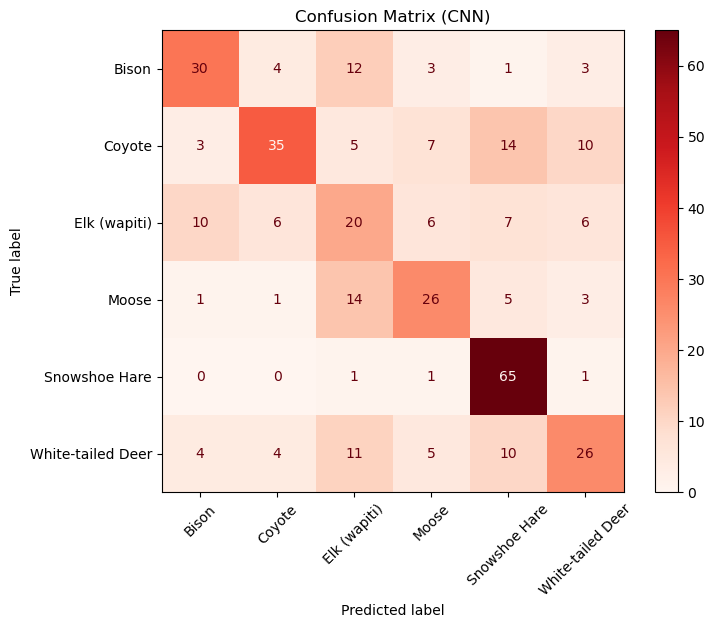

              precision    recall  f1-score   support

           0       0.62      0.57      0.59        53
           1       0.70      0.47      0.56        74
           2       0.32      0.36      0.34        55
           3       0.54      0.52      0.53        50
           4       0.64      0.96      0.76        68
           5       0.53      0.43      0.48        60

    accuracy                           0.56       360
   macro avg       0.56      0.55      0.54       360
weighted avg       0.57      0.56      0.55       360



In [31]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Reds", xticks_rotation=45)
plt.title("Confusion Matrix (CNN)")
plt.show()

print(classification_report(all_labels, all_preds))

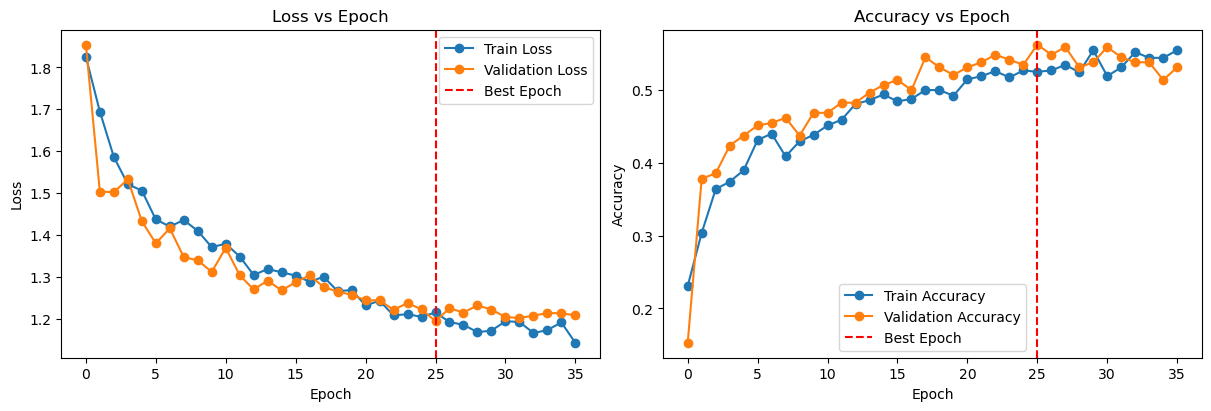

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

#Plot training and test loss.
axes[0].plot(train_losses, marker="o", label="Train Loss")
axes[0].plot(val_losses, marker="o", label="Validation Loss")
# Early stopping line
axes[0].axvline(x=best_epoch - 1, color='red', linestyle='--', label='Best Epoch')
axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot training and test accuracy.
axes[1].plot(train_accs, marker="o", label="Train Accuracy")
axes[1].plot(val_accs, marker="o", label="Validation Accuracy")
# Early stopping line
axes[1].axvline(x=best_epoch - 1, color='red', linestyle='--', label='Best Epoch')
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.show()

In [34]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

# reverse mapping
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}

def predict_image(image_path, model, device, transform, resize=(256, 256)):
    # load image
    img = Image.open(image_path).convert("RGB")

    # resize to match training pipeline
    img = img.resize(resize, Image.BILINEAR)

    # convert to numpy
    img_np = np.array(img).astype("float32") / 255.0

    # apply same validation transform
    img_tensor = transform(image=img_np)["image"].float().unsqueeze(0).to(device)

    # predict
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        pred_idx = torch.argmax(outputs, dim=1).item()
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]

    pred_class = idx_to_class[pred_idx]
    confidence = probs[pred_idx]

    return pred_class, confidence, img

In [ ]:
image_paths = [
    "/content/drive/MyDrive/DATA-607/Project/Liam Images/Copy of bison.jpg",
    "/content/drive/MyDrive/DATA-607/Project/Liam Images/Copy of IMG_2954.png"
]

for image_path in image_paths:
    pred_class, confidence, img = predict_image(
        image_path=image_path,
        model=model,
        device=device,
        transform=val_transform
    )

    print(f"{image_path}")
    print(f"Prediction: {pred_class} ({confidence:.4f})")

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis("off")
    plt.show()